In [1]:

import time
import pandas as pd
import numpy as np
import sys
import os
import pathlib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms import VQE
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.primitives import StatevectorEstimator
import numpy as np


notebook_dir = pathlib.Path().resolve()
parent_dir = notebook_dir.parent
sys.path.append(str(parent_dir))

from MomentumMonteCarlo import momentum_sa_merged
from MomentumBuilder import MomentumBuilder as mb
from MomentumMonteCarlo import momentum_sa_phased


from scipy.optimize import minimize
from AnsatzBenchmarking.Builders.momentumBuilder import MomentumBuilder
from AnsatzBenchmarking.Builders.momentumMonteCarloBuilder import MonteCarloMomentumBuilder
from AnsatzBenchmarking.Builders.mergedMomentumBuilder import mergedMomentumBuilder
from AnsatzBenchmarking.Builders.fixedSU2 import FixedSU2Builder as EfficientSU2Builder
from AnsatzBenchmarking.Problems.tsp.TSPProblems import TSPProblemSet
from AnsatzBenchmarking.Builders.base import AnsatzBuilder
from AnsatzBenchmarking.Problems.base import ProblemSet
from Utilities import cost_func, Estimator
from SLSQP import slsqp

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:
def evaluate_builder(builder, problems, trials=10):
    import time
    import numpy as np
    from qiskit.primitives import StatevectorEstimator
    from qiskit.circuit import Parameter, QuantumCircuit

    results = []
    estimator = StatevectorEstimator()
    problemSet = problems.getProblemSet()

    for problem_idx, (h, exact) in enumerate(problemSet):
        print(f"\nProblem {problem_idx+1}")
        
        for trial in range(trials):
            H = -h

            n_qubits = H.num_qubits
            circuit = QuantumCircuit(n_qubits)
            ansatz = QuantumCircuit(n_qubits)

            for q in range(n_qubits): 
                pName = f"angle{q}" 
                p = Parameter(pName)
                ansatz.rx(p, q)

            paramsList = [1] * n_qubits        
            paramsIndex = list(range(n_qubits))
            
    
            observables = [*H.paulis, H]

            start = time.time()
            
            # Momentum Builder takes slightly different input parameters, so this is needed
            if builder.__name__ == "MomentumBuilder":
                circuit, opt_params = builder(
                    paramsList, paramsIndex, ansatz, circuit, observables, 
                    estimator, 0.9, 0.99, iters=3, return_ansatz_and_params=True
                )
            else:
                circuit, opt_params = builder(
                    paramsList, paramsIndex, ansatz, circuit, H, 
                    estimator, 0.9, 0.99, iters=3, optimization_runs=600
                )
                
            build_time = time.time() - start

            raw = estimator.run([(circuit, H, opt_params)])
            final_energy = -1 * float(np.real(raw.result()[0].data.evs))

            error = abs(final_energy - exact)
            
            print(f"Trial {trial+1}/{trials},  Energy: {final_energy:.4f} (Exact: {exact}), Time: {build_time:.2f}s")

            results.append({
                "ansatz_type": builder.__name__,
                "problem_index": problem_idx + 1,
                "trial": trial + 1,
                "time": build_time,
                "energy": -final_energy,
                "exact_energy": -exact,
                "error": error,
                "params": len(opt_params),
            })

    return results

In [3]:
# Load problem set and run benchmarks
print("Loading TSP problem set...")
problem_set = TSPProblemSet()
problems = problem_set.getProblemSet()
print(f"Loaded {len(problems)} TSP problems\n")

print("Running benchmarks...")
print("="*60)

Loading TSP problem set...
Loaded 12 TSP problems

Running benchmarks...


In [4]:
# Evaluate MomentumBuilder
print("\n" + "="*60)
print("MomentumBuilder:")
print("="*60)
momentum_results = evaluate_builder(mb, problem_set, trials=5)


MomentumBuilder:

Problem 1
Trial 1/5,  Energy: -59.2573 (Exact: -6.0), Time: 2.30s
Trial 2/5,  Energy: -59.2573 (Exact: -6.0), Time: 2.26s
Trial 3/5,  Energy: -59.2573 (Exact: -6.0), Time: 2.23s
Trial 4/5,  Energy: -59.2573 (Exact: -6.0), Time: 2.28s
Trial 5/5,  Energy: -59.2573 (Exact: -6.0), Time: 2.28s

Problem 2
Trial 1/5,  Energy: -90.7952 (Exact: -5.0), Time: 2.25s
Trial 2/5,  Energy: -90.7952 (Exact: -5.0), Time: 2.28s
Trial 3/5,  Energy: -90.7952 (Exact: -5.0), Time: 2.26s
Trial 4/5,  Energy: -90.7952 (Exact: -5.0), Time: 2.30s
Trial 5/5,  Energy: -90.7952 (Exact: -5.0), Time: 2.25s

Problem 3
Trial 1/5,  Energy: -56.3575 (Exact: -4.0), Time: 2.25s
Trial 2/5,  Energy: -56.3575 (Exact: -4.0), Time: 2.27s
Trial 3/5,  Energy: -56.3575 (Exact: -4.0), Time: 2.27s
Trial 4/5,  Energy: -56.3575 (Exact: -4.0), Time: 2.29s
Trial 5/5,  Energy: -56.3575 (Exact: -4.0), Time: 2.29s

Problem 4
Trial 1/5,  Energy: -69.1366 (Exact: -6.0), Time: 2.31s
Trial 2/5,  Energy: -69.1366 (Exact: -6.0)

In [5]:
# Evaluate EfficientSU2
#print(f"\n{'='*60}")
#print("EfficientSU2:")
#print("="*60)
#su2_results = evaluate_builder(EfficientSU2Builder, problem_set, trials=1)

In [6]:
# Evaluate phasedMomentumBuilder
print("\n" + "="*60)
print("Phased MomentumBuilder:")
print("="*60)
phased_momentum_results = evaluate_builder(momentum_sa_phased, problem_set, trials=5)


Phased MomentumBuilder:

Problem 1
Energy after MomentumBuilder:  59.25728434940166
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  10.143125894005326
Trial 1/5,  Energy: -10.1431 (Exact: -6.0), Time: 32.81s
Energy after MomentumBuilder:  59.25728434940166
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  7.493886680755226
Trial 2/5,  Energy: -7.4939 (Exact: -6.0), Time: 32.66s
Energy after MomentumBuilder:  59.25728434940166
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  8.767597710608369
Trial 3/5,  Energy: -8.7676 (Exact: -6.0), Time: 32.12s
Energy after MomentumBuilder:  59.25728434940166
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  8.218862937436448
Trial 4/5,  Energy: -8.2189 (Exact: -6.0), Time: 32.37s
Energy after MomentumBuilder:  59.25728434940166
Energy after MomentumBuilder and Simulated Annealing (SA), two-phased:  8.64523957691338
Trial 5/5,  Energy: -8.6452 (Exact: -6.0), T

In [7]:
# Evaluate mergedMomentumBuilder
print("\n" + "="*60)
print("Merged MomentumBuilder:")
print("="*60)
merged_momentum_results = evaluate_builder(momentum_sa_merged, problem_set, trials=5)


Merged MomentumBuilder:

Problem 1
Energy after merged MB and SA:  7.989667860966019
Trial 1/5,  Energy: -7.9897 (Exact: -6.0), Time: 72.34s
Energy after merged MB and SA:  8.98803074622389
Trial 2/5,  Energy: -8.9880 (Exact: -6.0), Time: 70.59s
Energy after merged MB and SA:  23.98342377919215
Trial 3/5,  Energy: -23.9834 (Exact: -6.0), Time: 70.83s
Energy after merged MB and SA:  12.708976267403013
Trial 4/5,  Energy: -12.7090 (Exact: -6.0), Time: 72.98s
Energy after merged MB and SA:  10.529582014732101
Trial 5/5,  Energy: -10.5296 (Exact: -6.0), Time: 69.94s

Problem 2
Energy after merged MB and SA:  7.563947235656771
Trial 1/5,  Energy: -7.5639 (Exact: -5.0), Time: 68.28s
Energy after merged MB and SA:  10.862878762009545
Trial 2/5,  Energy: -10.8629 (Exact: -5.0), Time: 72.87s
Energy after merged MB and SA:  6.884507104339047
Trial 3/5,  Energy: -6.8845 (Exact: -5.0), Time: 71.94s
Energy after merged MB and SA:  7.629854030270183
Trial 4/5,  Energy: -7.6299 (Exact: -5.0), Time: 

In [8]:
# Combine results
all_results = momentum_results + merged_momentum_results + phased_momentum_results 
df = pd.DataFrame(all_results)
print(f"\n{'='*60}")
print(f"Completed: {len(df)} successful trials")


Completed: 180 successful trials


In [27]:
# Display summary statistics
if len(df) > 0:
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    
    import pandas as pd

    # 1. Generate your summary table
    summary = df.groupby('ansatz_type').agg({
        'energy': ['mean', 'std', 'min', 'max'],
        'time': ['mean', 'std', 'min', 'max'],
        'error': ['mean', 'std', 'min', 'max']
    })

    print("Energy")
    print(summary['energy'].to_string())

    print("\nTime")
    print(summary['time'].to_string())

    print("\nError")
    print(summary['error'].to_string())
else:
    print("⚠ No successful trials to display.")




SUMMARY STATISTICS
Energy
                         mean        std        min         max
ansatz_type                                                    
MomentumBuilder     80.038421  13.837481  56.357549  102.451859
momentum_sa_merged  16.219243   7.148494   5.129167   31.327994
momentum_sa_phased  17.266705   7.812476   4.793182   33.535744

Time
                         mean       std        min        max
ansatz_type                                                  
MomentumBuilder      2.275515  0.068097   2.152108   2.424557
momentum_sa_merged  71.242020  2.400643  66.369361  75.385721
momentum_sa_phased  32.353581  1.286326  30.011034  35.283566

Error
                         mean        std        min        max
ansatz_type                                                   
MomentumBuilder     70.038421  10.677438  52.357549  85.795209
momentum_sa_merged   6.219243   5.200234   0.876078  20.262616
momentum_sa_phased   7.266705   5.555284   0.793182  19.535744


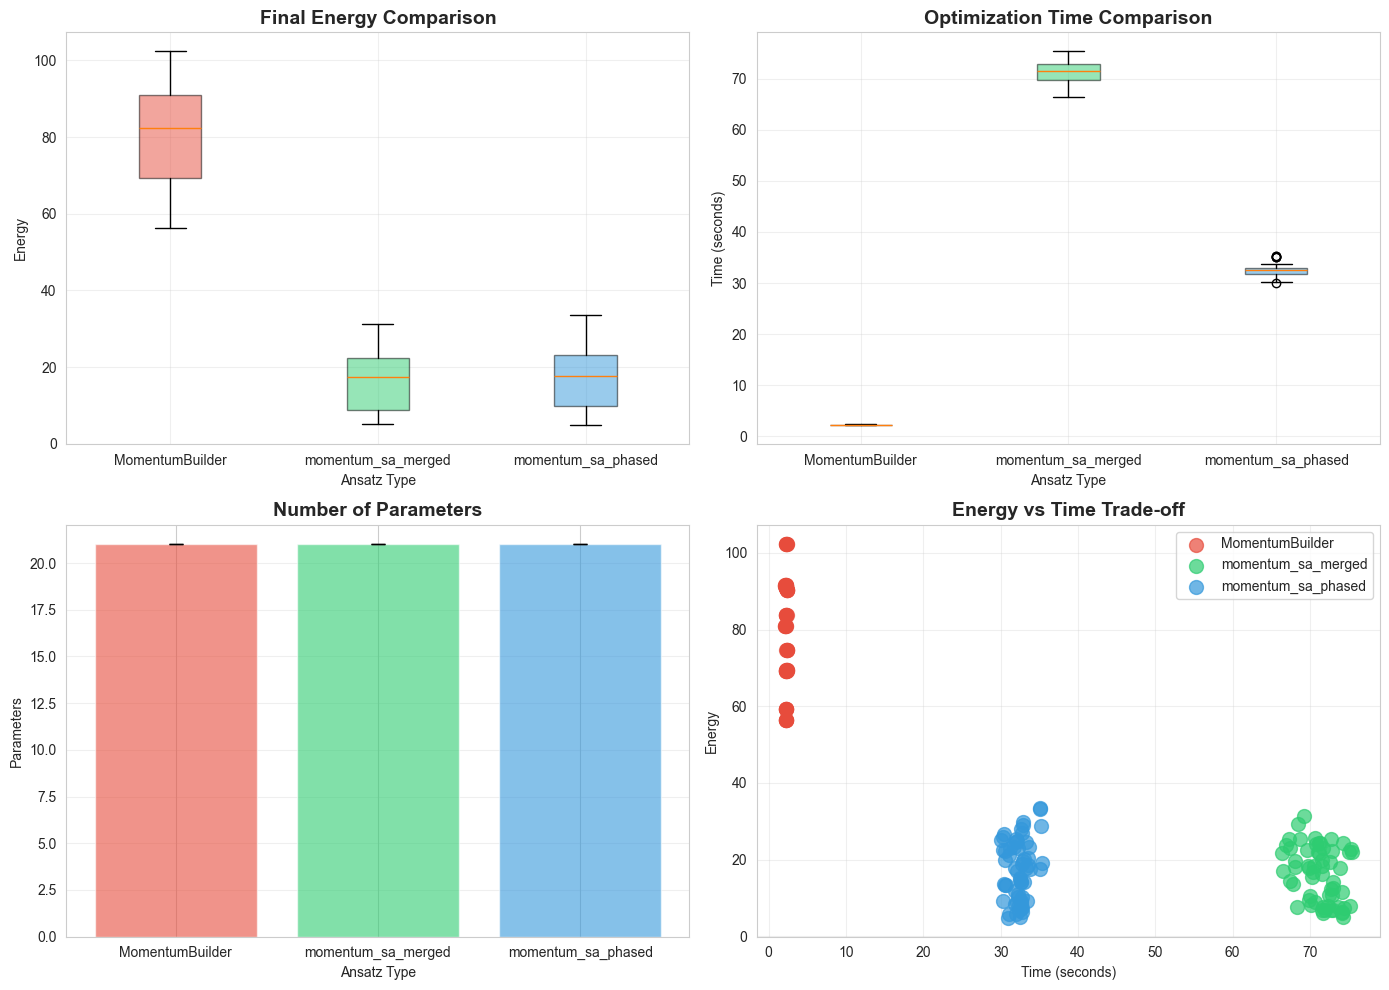

In [10]:
# Visualization 1: Main comparison plots
if len(df) > 0 and 'ansatz_type' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Get unique ansatz types to ensure consistent ordering
    ansatz_types = df['ansatz_type'].unique()
    
    # Define colors (Red, Green, Blue, yellow) to handle up to 4 builders
    colors = ['#e74c3c', '#2ecc71', '#3498db', '#BA8E23']
    
    
    # 1. Energy comparison
    ax1 = axes[0, 0]
    energy_data = [df[df['ansatz_type'] == atype]['energy'].dropna().values for atype in ansatz_types]
    bplot1 = ax1.boxplot(energy_data, labels=ansatz_types, patch_artist=True)
    
    # Apply translucent colors to the energy boxes
    for patch, color in zip(bplot1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5) # Translucent
        
    ax1.set_title('Final Energy Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ansatz Type')
    ax1.set_ylabel('Energy')
    ax1.grid(True, alpha=0.3)
    
    # 2. Time comparison
    ax2 = axes[0, 1]
    time_data = [df[df['ansatz_type'] == atype]['time'].dropna().values for atype in ansatz_types]
    bplot2 = ax2.boxplot(time_data, labels=ansatz_types, patch_artist=True)
    
    # Apply translucent colors to the time boxes
    for patch, color in zip(bplot2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5) # Translucent
        
    ax2.set_title('Optimization Time Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ansatz Type')
    ax2.set_ylabel('Time (seconds)')
    ax2.grid(True, alpha=0.3)
    
    # 3. Parameters comparison
    ax3 = axes[1, 0]
    param_means = df.groupby('ansatz_type')['params'].mean()
    param_stds = df.groupby('ansatz_type')['params'].std()
    x_pos = np.arange(len(param_means))

    
    bar_colors = [colors[list(ansatz_types).index(idx)] for idx in param_means.index]
    
    ax3.bar(x_pos, param_means.values, yerr=param_stds.values, 
            color=bar_colors, alpha=0.6, capsize=5) # Translucent bars
    ax3.set_title('Number of Parameters', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Ansatz Type')
    ax3.set_ylabel('Parameters')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(param_means.index, rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Energy vs Time scatter
    ax4 = axes[1, 1]
    for idx, ansatz_type in enumerate(ansatz_types):
        subset = df[df['ansatz_type'] == ansatz_type]
        ax4.scatter(subset['time'], subset['energy'], 
                   label=ansatz_type, color=colors[idx % len(colors)], alpha=0.7, s=100)
                   
    ax4.set_title('Energy vs Time Trade-off', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Energy')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ansatz_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 1. Energy comparison
    ax1 = axes[0, 0]
    energy_data = [df[df['ansatz_type'] == atype]['energy'].dropna().values for atype in ansatz_types]
    bplot1 = ax1.boxplot(energy_data, labels=ansatz_types, patch_artist=True)
    
    # Apply translucent colors to the energy boxes
    for patch, color in zip(bplot1['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5) # Translucent
        
    ax1.set_title('Final Energy Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Ansatz Type')
    ax1.set_ylabel('Energy')
    ax1.grid(True, alpha=0.3)
    
    # 2. Time comparison
    ax2 = axes[0, 1]
    time_data = [df[df['ansatz_type'] == atype]['time'].dropna().values for atype in ansatz_types]
    bplot2 = ax2.boxplot(time_data, labels=ansatz_types, patch_artist=True)
    
    # Apply translucent colors to the time boxes
    for patch, color in zip(bplot2['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.5) # Translucent
        
    ax2.set_title('Optimization Time Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Ansatz Type')
    ax2.set_ylabel('Time (seconds)')
    ax2.grid(True, alpha=0.3)
    
    # 3. Parameters comparison
    ax3 = axes[1, 0]
    param_means = df.groupby('ansatz_type')['params'].mean()
    param_stds = df.groupby('ansatz_type')['params'].std()
    x_pos = np.arange(len(param_means))
    
    # Ensure bar colors match the exact order of the groupby index
    bar_colors = [colors[list(ansatz_types).index(idx)] for idx in param_means.index]
    
    ax3.bar(x_pos, param_means.values, yerr=param_stds.values, 
            color=bar_colors, alpha=0.6, capsize=5) # Translucent bars
    ax3.set_title('Number of Parameters', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Ansatz Type')
    ax3.set_ylabel('Parameters')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(param_means.index, rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Energy vs Time scatter
    ax4 = axes[1, 1]
    for idx, ansatz_type in enumerate(ansatz_types):
        subset = df[df['ansatz_type'] == ansatz_type]
        ax4.scatter(subset['time'], subset['energy'], 
                   label=ansatz_type, color=colors[idx % len(colors)], alpha=0.7, s=100)
                   
    ax4.set_title('Energy vs Time Trade-off', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Time (seconds)')
    ax4.set_ylabel('Energy')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ansatz_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()